# CS 136 day03 Lecture Notebook: Beta distribution and Beta-Bernoulli models

In [ ]:
import numpy as np
import scipy.stats

import warnings
warnings.filterwarnings(action='ignore')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)

# Part 1: Beta Distribution Visualized

## Beta distribution as a PDF

#### Formal definition: 

$$
\text{Beta}(\mu | a, b) = \frac{1}{C(a, b)} \cdot \mu^{a-1} (1-\mu)^{b-1}
$$

#### Standard Numerical implementations

Thankfully, you can use the built-in functions from SciPy to compute this function:

* `stats.beta.pdf(\cdot)` computes the pdf
* `stats.beta.logpdf(\cdot)` computes the natural log of the pdf
* * Will often be more numerically stable than doing `np.log(stats.beta.pdf(\cdot))`

See <https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.beta.html>


## Visualization: PDF across different values of hyperparameters a, b

We'll make a grid plot, where each grid cell shows the PDF for a single $a, b$ pair.


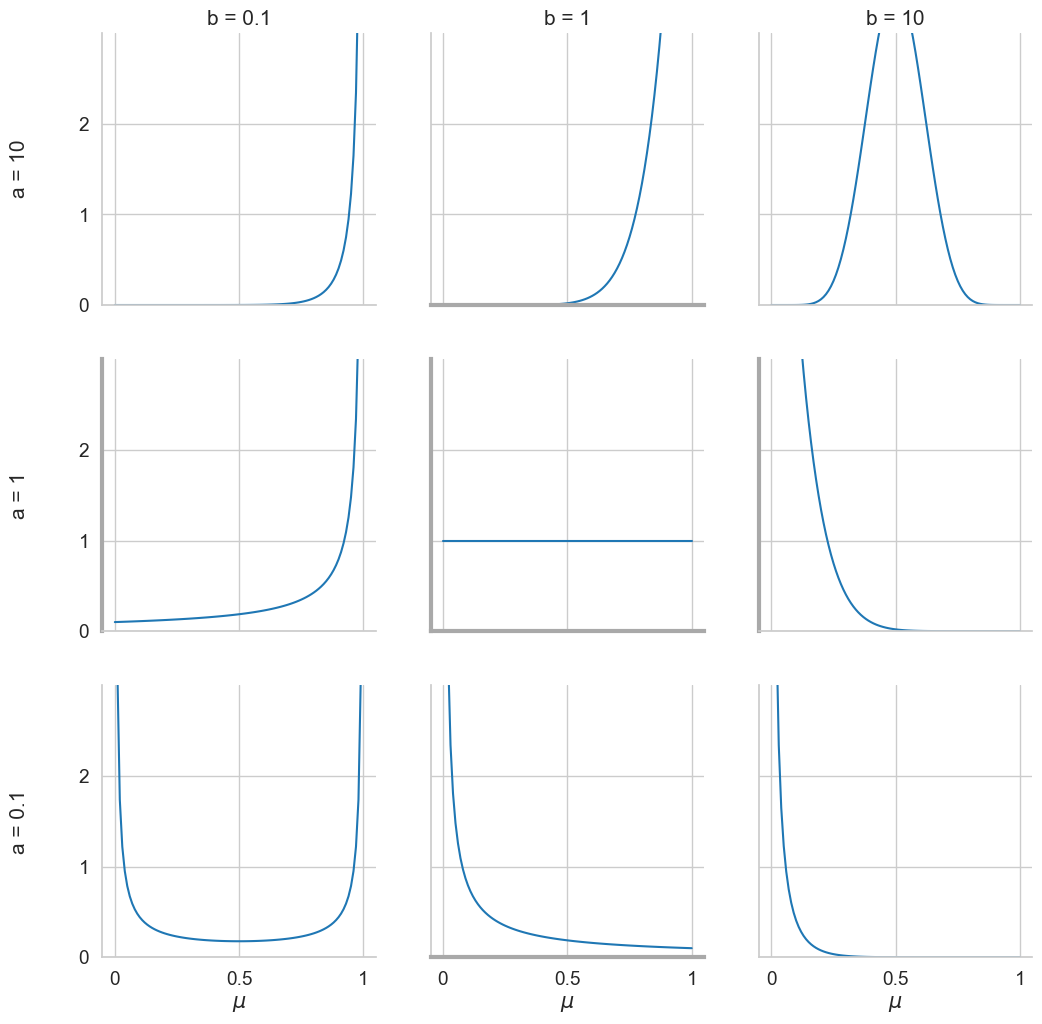

In [ ]:
agrid_G = np.asarray([0.1, 1.0, 10.0])
bgrid_H = np.asarray([0.1, 1.0, 10.0])
G = agrid_G.size
H = bgrid_H.size

mu_vals = np.linspace(0.0001, 0.9999, 101)

fig, axgrid = plt.subplots(nrows=len(agrid_G), ncols=len(bgrid_H), sharex=True, sharey=True, figsize=(12, 12));
axgrid = axgrid[::-1] # flip order of rows

for gg in range(G):
    for hh in range(H):
        
        # Form Beta distribution object using current a,b parameters
        cur_beta_dist = scipy.stats.beta(agrid_G[gg], bgrid_H[hh])
        
        # Evaluate Beta PDF at each candidate value of mu in "mu_vals"
        pdf_vals = cur_beta_dist.pdf(mu_vals)
            
        axgrid[gg, hh].plot(mu_vals, pdf_vals, '-')
        if hh == 0:
            axgrid[gg, hh].set_ylabel('a = %.2g\n\n' % agrid_G[gg]);
        if gg == G - 1:
            axgrid[gg, hh].set_title('b = %.2g' % bgrid_H[hh]);
        if gg == 0:
            axgrid[gg, hh].set_xlabel('$\mu$');

        if agrid_G[gg] == 1.0:
            axgrid[gg, hh].spines['left'].set_linewidth(3)
            axgrid[gg, hh].spines['left'].set_color('darkgray')
        if bgrid_H[hh] == 1.0:
            axgrid[gg, hh].spines['bottom'].set_linewidth(3)
            axgrid[gg, hh].spines['bottom'].set_color('darkgray')

H = 3.0
B = 0.05
sns.despine(fig)
axgrid[0,0].set_ylim(0, H); axgrid[0,0].set_yticks(np.arange(0, H, 1.0));
axgrid[0,0].set_xlim(-B, 1+ B); axgrid[0,0].set_xticks([0, 0.5, 1.0]); axgrid[0,0].set_xticklabels(['0', '0.5', '1']);

## Generate and display 20 samples from a Beta(10, 10)

In [ ]:
a = 10
b = 10
mu_samples = scipy.stats.beta(a,b).rvs(20)

mu_samples

array([0.62683611, 0.45474143, 0.44534875, 0.45924928, 0.48616283,
       0.45769945, 0.61307068, 0.46396101, 0.43762946, 0.44429693,
       0.5095901 , 0.42787159, 0.45748037, 0.40217784, 0.45198222,
       0.54569456, 0.49476663, 0.43230672, 0.44904176, 0.28095329])

## Generate and display 20 samples from a Beta(0.1, 0.1)

In [ ]:
a = 0.1
b = 0.1
mu_samples = scipy.stats.beta(a,b).rvs(20)

mu_samples

array([9.99998750e-01, 5.71491905e-01, 9.88173715e-01, 9.98446876e-01,
       9.85101233e-01, 9.66751978e-01, 2.17261736e-03, 2.20149775e-01,
       1.00000000e+00, 9.95251816e-01, 1.85032971e-01, 9.99726965e-01,
       9.99860392e-01, 9.99992535e-01, 4.93179728e-11, 4.04706459e-01,
       1.38900666e-05, 5.71071509e-03, 1.62301068e-07, 4.04587783e-03])

## Generate and display 20 samples from a Beta(0.001, 0.001)

In [ ]:
a = 0.001
b = 0.001
mu_samples = scipy.stats.beta(a,b).rvs(20)

mu_samples

array([0.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 9.99850451e-01, 1.00000000e+00, 5.03503838e-37,
       1.00000000e+00, 1.00000000e+00, 5.82037017e-94, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 0.00000000e+00,
       1.00000000e+00, 0.00000000e+00, 1.00000000e+00, 1.00000000e+00])

# Part 2: Posterior visualization in the Beta-Bernoulli model

We'll assume the model discussed in class

\begin{align}
p(\mu) &= \text{Beta}( \mu | a, b)
\\
p(x_1, \ldots x_N | \mu) &= \prod_{n=1}^N \text{Bern}( x_n | \mu)
\end{align}

## Calculating posterior parameters

In [ ]:
def calc_posterior_parameters(x_N, a, b):
    ''' Compute posterior parameters
    
    Args
    ----
    x_N : 1D array, size N
        Contains binary observations for each of N coin tosses
    a : float, positive
        Prior parameter, number of heads "pseudocounts"
    b : float, positive
        Prior parameter, number of tails "pseudocounts"
    
    Returns
    -------
    ahat : positive scalar
    bhat : positive scalar
    '''
    ahat = a + x_N.sum()
    bhat = b + x_N.shape[0] - x_N.sum()
    return ahat, bhat

## Draw 'fake' data from model:  N observed flips for a coin with 78.9% proba heads

In [ ]:
# Define a random generator object, with specific seed for reproducibility
prng = np.random.RandomState(101)

# Settings
N = 10000   # num coin tosses to observe

a = 1      # prior num of heads
b = 1      # prior num of tails

# Pick a "true" mu value for data generation
true_mu = 0.789

# Sample N examples from Bernoulli given mu
x_N = scipy.stats.bernoulli(true_mu).rvs(size=N, random_state=prng)
# OR...
# x_N = prng.rand(N) < true_mu # another equivalent way to draw N samples from a Bernoulli with parameter 'true_mu'

## Visualizing Posterior given the *true*, uniform prior

Visualize the posterior over mu for our "fake data" `x_N`

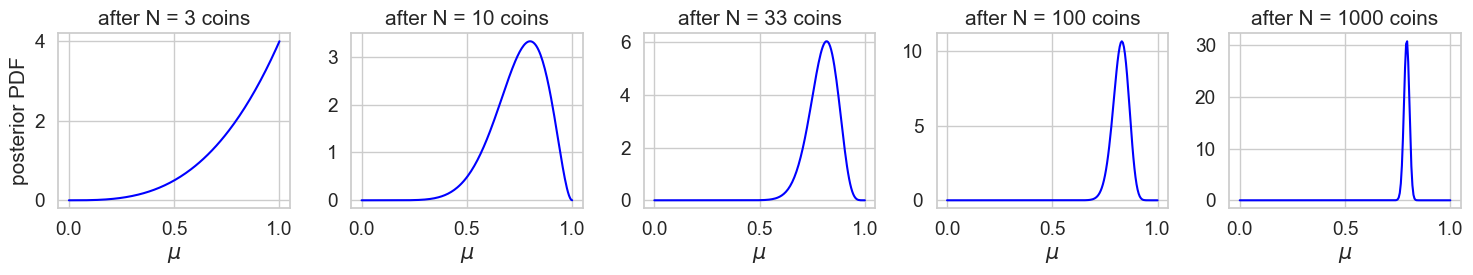

In [ ]:
Npartial_list = [3, 10, 33, 100, 1000]
L = len(Npartial_list)

fig, axgrid = plt.subplots(
    nrows=1, ncols=L,
    sharex=True, sharey=False,
    figsize=(3 * L, 3))

# Define a grid of mu values at which we'll evaluate the PDF
G = 201
mu_grid_G = np.linspace(0.0001, 0.9999, G)
for aa, Npartial in enumerate(Npartial_list):
    # Compute the parameters of the Beta posterior distribiution, using only first Npartial observations
    ahat, bhat = calc_posterior_parameters(x_N[:Npartial], a, b)

    # compute the posterior pdf over the grid mu_grid_G
    pdf_grid_G = scipy.stats.beta(ahat, bhat).pdf(mu_grid_G)
    
    axgrid[aa].plot(mu_grid_G, pdf_grid_G, 'b-')
    axgrid[aa].set_title("after N = %d coins" % Npartial)
    axgrid[aa].set_xlabel(r'$\mu$');
    if aa == 0:
        axgrid[aa].set_ylabel('posterior PDF');
plt.tight_layout();

## Visualizing Posterior given a misinformed prior

Repeat Exercise 2b using the *same* fake data, but act as if your prior was instead $a=3, b=20$ (in other words, quite confident in prior belief that the coin would be tails rather than heads.

This is a **misinformed** prior, because in reality the chance of a heads is 78.9%

Visualize the posterior over mu for our "fake data" `x_N`, after seeing each of the Npartial examples as in 2b.

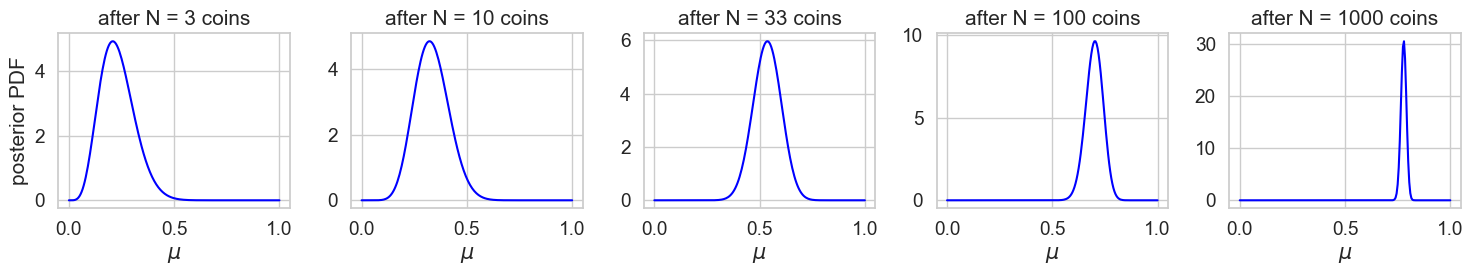

In [ ]:
abad =  3
bbad = 20

# Same code as before, but now using abad, bbad
Npartial_list = [3, 10, 33, 100, 1000]
L = len(Npartial_list)

fig, axgrid = plt.subplots(
    nrows=1, ncols=L,
    sharex=True, sharey=False,
    figsize=(3 * L, 3))

# Define a grid of mu values at which we'll evaluate the PDF
G = 201
mu_grid_G = np.linspace(0.0001, 0.9999, G)
for aa, Npartial in enumerate(Npartial_list):
    # Compute the parameters of the Beta posterior distribiution, using only first Npartial observations
    ahat, bhat = calc_posterior_parameters(x_N[:Npartial], abad, bbad)

    # compute the posterior pdf over the grid mu_grid_G
    pdf_grid_G = scipy.stats.beta(ahat, bhat).pdf(mu_grid_G)
    
    axgrid[aa].plot(mu_grid_G, pdf_grid_G, 'b-')
    axgrid[aa].set_title("after N = %d coins" % Npartial)
    axgrid[aa].set_xlabel(r'$\mu$');
    if aa == 0:
        axgrid[aa].set_ylabel('posterior PDF');
plt.tight_layout();

## Discussion Question: Does having a misinformed prior matter?

How does your answer depend on how much data is available?